In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "train.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "rohitsahoo/sales-forecasting",
    file_path
)

print(" Dataset Loaded Successfully")

/tmp/ipython-input-372/3144364041.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 480k/480k [00:00<00:00, 69.8MB/s]

Extracting zip of train.csv...
 Dataset Loaded Successfully


In [2]:
print("\n => First 5 Rows:")
print(df.head())

print("\n => Dataset Shape:", df.shape)

print("\n => Column Names:")
print(df.columns)

print("\n => Dataset Info:")
print(df.info())

print("\n => Summary Statistics:")
print(df.describe())



 => First 5 Rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Pro

In [3]:


data_dictionary = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Description": ["Description not provided"] * len(df.columns)
})

print(" Data Dictionary:")
data_dictionary

 Data Dictionary:


,Column Name,Data Type,Description
0,Row ID,int64,Description not provided
1,Order ID,object,Description not provided
2,Order Date,object,Description not provided
3,Ship Date,object,Description not provided
4,Ship Mode,object,Description not provided
5,Customer ID,object,Description not provided
6,Customer Name,object,Description not provided
7,Segment,object,Description not provided
8,Country,object,Description not provided
9,City,object,Description not provided



 => Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

 => Duplicate Rows: 0


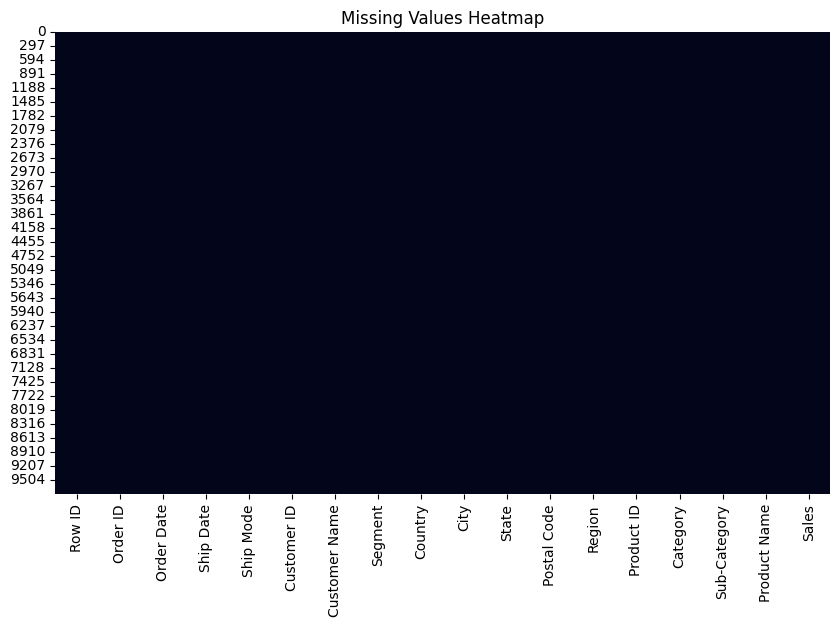

In [4]:


print("\n => Missing Values:")
print(df.isnull().sum())

print("\n => Duplicate Rows:", df.duplicated().sum())


plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [5]:



df.drop_duplicates(inplace=True)


if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])


numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)


categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\n Data Cleaning Completed")




 Data Cleaning Completed


/tmp/ipython-input-372/2689406292.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-372/2689406292.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [6]:


# Example: Extract year, month if Date exists
if 'Date' in df.columns:
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day

# Example: If Sales column exists
if 'Sales' in df.columns:
    df['Log_Sales'] = np.log1p(df['Sales'])

print("\n Feature Engineering Completed")



 Feature Engineering Completed


In [7]:


if 'Sales' in df.columns:
    Q1 = df['Sales'].quantile(0.25)
    Q3 = df['Sales'].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df['Sales'] < Q1 - 1.5*IQR) |
                  (df['Sales'] > Q3 + 1.5*IQR)]

    print("\n Number of Outliers in Sales:", outliers.shape[0])



 Number of Outliers in Sales: 1145


In [9]:


df.to_csv("cleaned_sales_data.csv", index=False)

print("\n Cleaned dataset saved as 'cleaned_sales_data.csv'")
print("\n TASK COMPLETED SUCCESSFULLY")


 Cleaned dataset saved as 'cleaned_sales_data.csv'

 TASK COMPLETED SUCCESSFULLY
